# **Taxis Dataset Analysis**

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi']=110
sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


SECTION1 Load&Inspect

In [46]:
df=sns.load_dataset("taxis")

print('shape:',df.shape)
print(df.head())
print("structural info:",df.info())
print("Numeric Summary:",df.describe())

shape: (6433, 14)
               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper Wes

The dataset contains detailed records of taxirides, including pickup and drop-off times,passenger counts,fares,distances and payment types.It is commonly used for analyzing trip patterns,pricing behaviour and relationship between travel time codt and distance.

**Section2 -Clean & prepare**

In [47]:
print("shape before cleaning:",df.shape)

#step1-inspect missing values
print('Missing value in each column')
print(df.isnull().sum())

#step2-Handle missing values
df=df.dropna()

#step3 feature engineering
#convert to datetime(safe conversion)
df['pickup']=pd.to_datetime(df['pickup'])
df['dropoff']=pd.to_datetime(df['dropoff'])

#create trip duration(in minutes)
df['trip_duration']=(df['dropoff']-df['pickup']).dt.total_seconds()/60

#create fare per km feature
df['fare_per_km']=df['fare']/df['distance']

# step4 Drop irrevelant columns
df=df.drop(columns=['pickup','dropoff'])

print('shape after cleaning:',df.shape)


shape before cleaning: (6433, 14)
Missing value in each column
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64
shape after cleaning: (6341, 14)


the dataset is cleaned by removing rows with missing values to ensure data quality for analysis.added trip duration and fare per km are created to enhance insights, and unnecessary datetime columns are dropped to simplify data

**Section3-Explore with statistics**

In [48]:
# calculating percentiles
print("50th percentile fare:",np.percentile(df['fare'],50))
print("25th percentile fare:",np.percentile(df['fare'],25))
print("75th percentile fare:",np.percentile(df['fare'],75))

50th percentile fare: 9.5
25th percentile fare: 6.5
75th percentile fare: 15.0


Groupby aggerations

In [49]:
# Avg fare by payment type
avg_fare_by_payment=df.groupby('payment')['fare'].mean()
print("Average fare by payment:",avg_fare_by_payment)

#Total trips by passenger count
total_trips_by_passenger=df.groupby('passengers')['fare'].count().sort_values(ascending=False)
print("Total trips by passenger count:",total_trips_by_passenger)

Average fare by payment: payment
cash           11.259053
credit card    13.531098
Name: fare, dtype: float64
Total trips by passenger count: passengers
1    4608
2     865
5     277
3     240
6     152
4     109
0      90
Name: fare, dtype: int64


pivot table

In [50]:
pivot=pd.pivot_table(df,values='fare',index='payment',columns='passengers',aggfunc='mean')
print("pivot table(avg fare):",pivot)

pivot table(avg fare): passengers           0          1         2         3          4          5  \
payment                                                                       
cash         13.576923  10.956505  11.65000  12.00000  11.603448  12.314103   
credit card  12.532468  13.672369  13.32314  13.37037  13.650000  12.668342   

passengers           6  
payment                 
cash         14.184211  
credit card  12.859649  


summary

In [51]:
print('---summary---')
print(f'Average fare per km: {df["fare"].mean():.2f}')
print(f'Maximum fare per km: {df["fare"].max():.2f}')
print(f'Minimum fare per km: {df["fare"].min():.2f}')
print(f'Total trips: {df.shape[0]}')
print(f'Total passengers: {df["passengers"].sum()}')
print(f'most common payment type: {df["payment"].value_counts().idxmax()}')

---summary---
Average fare per km: 12.89
Maximum fare per km: 150.00
Minimum fare per km: 1.00
Total trips: 6341
Total passengers: 9791
most common payment type: credit card


**Section 4 -Visualize**

bar chart


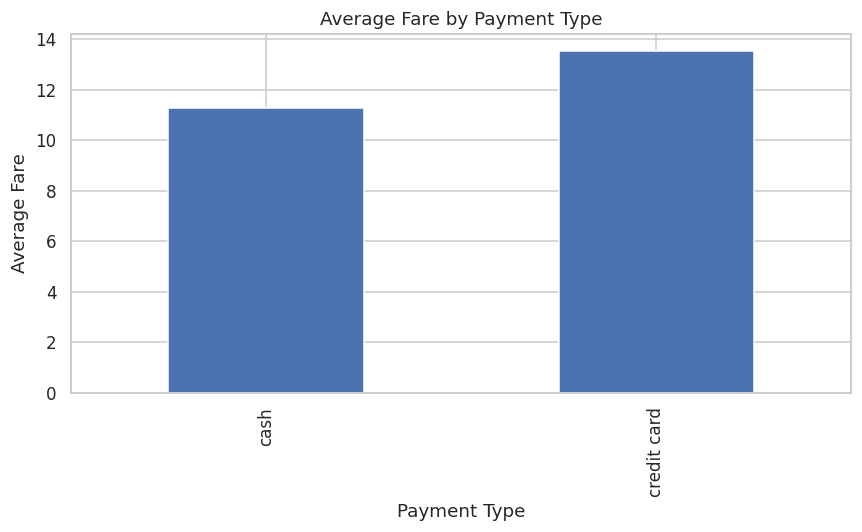

In [52]:
fig, ax= plt.subplots(figsize=(8,5))
avg_fare_by_payment=df.groupby('payment')['fare'].mean()
avg_fare_by_payment.plot(kind='bar',ax=ax)
ax.set_xlabel('Payment Type')
ax.set_ylabel('Average Fare')
ax.set_title('Average Fare by Payment Type')
plt.tight_layout()
plt.show()

Histogram

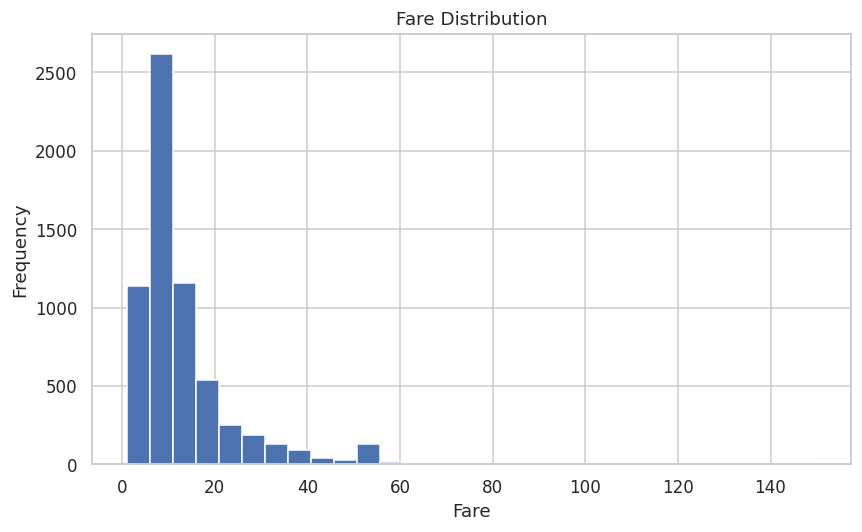

In [53]:
fig, ax= plt.subplots(figsize=(8,5))
ax.hist(df['fare'],bins=30)
ax.set_xlabel('Fare')
ax.set_ylabel('Frequency')
ax.set_title('Fare Distribution')
plt.tight_layout()
plt.show()

Scatter plot with annotation

<function matplotlib.pyplot.show(close=None, block=None)>

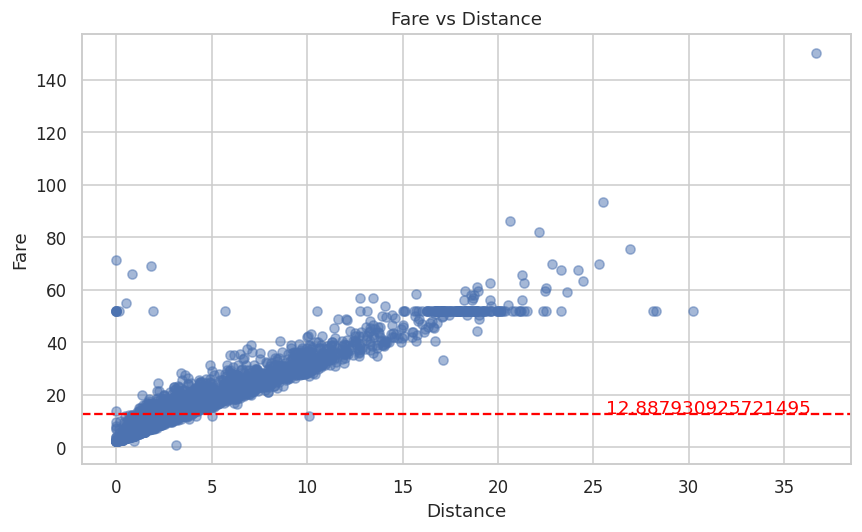

In [54]:
fig, ax= plt.subplots(figsize=(8,5))
ax.scatter(df['distance'],df['fare'],alpha=0.5)

#add reference line (avg fare)
mean_fare=df['fare'].mean()
ax.axhline(y=mean_fare,color='red',linestyle='--')
ax.annotate(mean_fare,xy=(df['distance'].max()*0.7,mean_fare),color='red')

ax.set_title("Fare vs Distance")
ax.set_xlabel('Distance')
ax.set_ylabel('Fare')
plt.tight_layout()
plt.show


Multipanel subplots

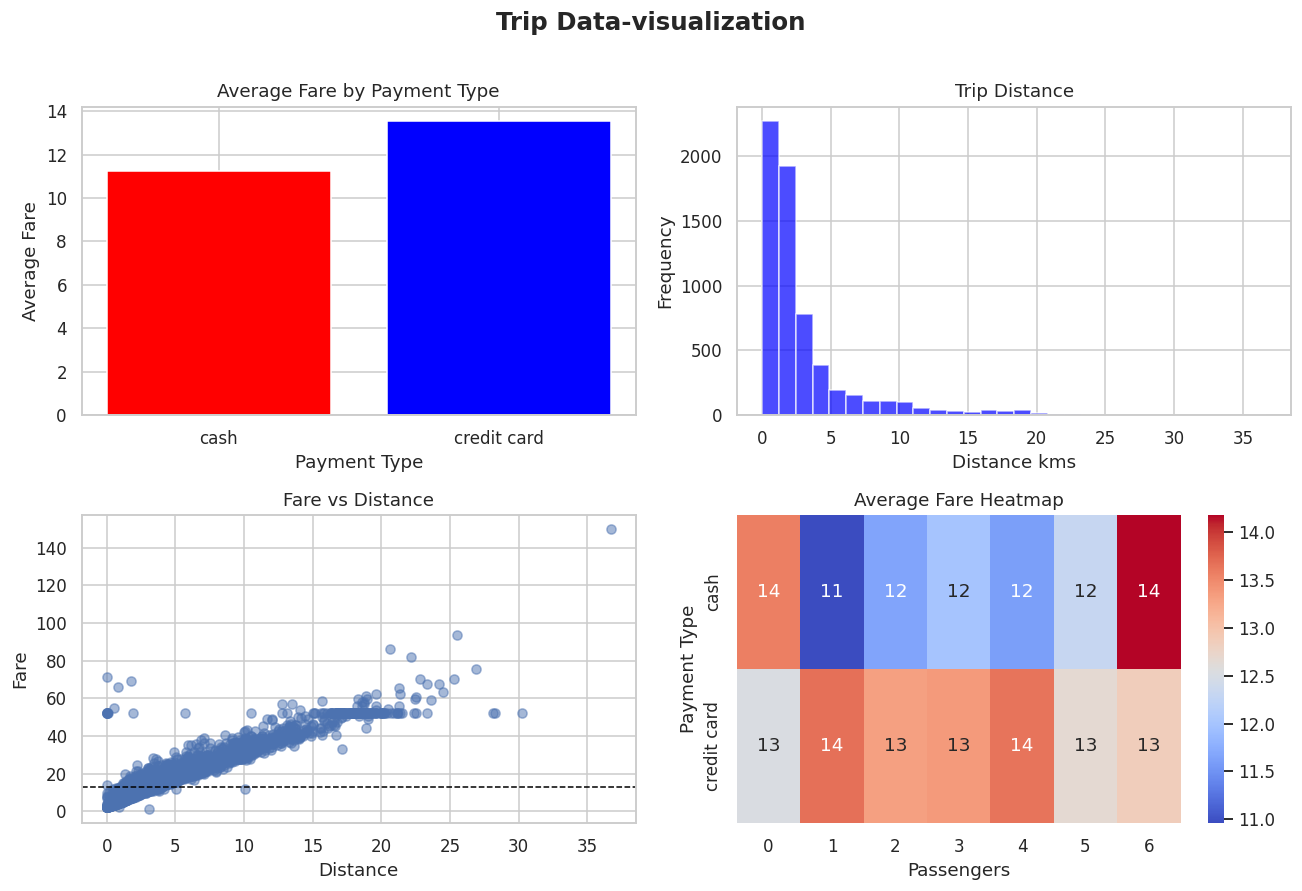

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes= plt.subplots(nrows=2,ncols=2,figsize=(12,8))
fig.suptitle("Trip Data-visualization",fontsize=16,fontweight='bold',y=1.01)

#panel A: Avg fare by payment type
ax=axes[0,0]
fare_payment=df.groupby('payment')['fare'].mean()
ax.bar(fare_payment.index,fare_payment.values, color=['red','blue','orange'])
ax.set_xlabel('Payment Type')
ax.set_ylabel('Average Fare')
ax.set_title('Average Fare by Payment Type')

# panel B: Trip distance distribution
ax=axes[0,1]
ax.hist(df['distance'],bins=30,color='blue', alpha=0.7)
ax.set_xlabel('Distance kms')
ax.set_ylabel('Frequency')
ax.set_title('Trip Distance')

# panel c: fare vs distance scatter
ax=axes[1,0]
ax.scatter(df['distance'],df['fare'],alpha=0.5)
ax.set_title("Fare vs Distance")
ax.set_xlabel('Distance')
ax.set_ylabel('Fare')

#add a reference line(mean fare)
ax.axhline(df['fare'].mean(),color='black',linestyle='--',linewidth=1)

#panel D: average fare heatmap(payment and passengers)
ax=axes[1,1]
avg_fare_heatmap=df.pivot_table(values='fare',index='payment',columns='passengers',aggfunc='mean')
sns.heatmap(avg_fare_heatmap,annot=True,cmap='coolwarm',ax=ax)
ax.set_title('Average Fare Heatmap')
ax.set_xlabel('Passengers')
ax.set_ylabel('Payment Type')
plt.tight_layout()
plt.show()

This dashboard provides a comprehensive overview of taxi trip patterns,showing how fare varies with payment methods, trip distance, and passenger count.It highlights the distance strongly influence fare,payment and passenger count to change in pricing behaviour

Section 5 Key Insights

1. Trips paid by credit card have a higher average fare other payment types

2. Distance strongly influence by fare charges

3. Payment type and passenger count introduce additional variations in pricing behaviour